# The Random Behaviour of Assets

Jun Shen
April 6, 2025

## 1. The Log-Normal Random Walk (Geometric Brownian Motion)

The continuous-time evolution of an asset price $S$ is described by the **Geometric Brownian Motion (GBM)** stochastic differential equation:

$$dS = \mu S dt + \sigma S dX$$

where:
* $\mu$ is the **drift** (expected return).
* $\sigma$ is the **volatility** (standard deviation of returns).
* $dX$ is a **Wiener Process** (Brownian Motion) with $\mathbb{E}[dX] = 0$ and $\text{Var}[dX] = dt$.

---

### Discrete Form and Returns

To implement this for statistical analysis, we discretize the formula over a time step $\delta t$. The return $R_t$ over this interval is:

$$R_{t} = \frac{S_{t+\delta t} - S_{t}}{S_{t}} = \underbrace{\mu \delta t}_{\text{Drift (Growth)}} + \underbrace{\sigma \sqrt{\delta t} \phi_{t}}_{\text{Diffusion (Risk)}}$$



**Key Definitions & Assumptions:**
1. **Parameter Source**: $\mu$ and $\sigma$ are the mean and standard deviation of the **daily returns** derived from the **overall dataset**, assuming that we have a daily price data in hand.
2. **Time Step ($\delta t$)**: Represents the number of days in the return period.
   - For a 1-day return: $\delta t = 1$.
   - For a 5-day return: $\delta t = 5$ (calculated using `periods=5`).
3. **Randomness**: $\phi_{t}$ is a random draw from a **Standard Normal Distribution**, i.e., $\phi_{t} \sim N(0,1)$.
4. **Diffusion Term**: Note that $dX \approx \phi_t \sqrt{\delta t}$ as $\delta t→ 0$. The square root $\sqrt{\delta t}$ ensures that variance scales linearly with time.

---

### The Random Walk Assumption

In many short-term quantitative models, if the drift is considered negligible ($\mu \delta t \approx 0$):

$$R_{t} = \sigma \sqrt{\delta t} \phi_{t}$$

In this simplified form, the return $R_t$ is purely driven by volatility and random shocks, where $R_t \sim N(0, \sigma^2 \delta t)$.

---

## 2. Implementation & Efficiency Notes

### A. Be Gentle to APIs (Avoid Rate Limiting)
Do not request multiple datasets for different frequencies from Yahoo Finance. This is inefficient and risks being rate-limited.
* **❌ Inefficient**: Downloading separate '1d', '5d', or '1wk' intervals.
* **✅ Best Practice**: Download the **raw daily data ('1d') once**, then handle all calculations locally.

```python
# Download once, compute many
snp = yf.download('SPY', start='1993-02-01', progress=False)['Close']
```

### **B. The Pitfalls of Slicing (Why `snp[::5]` is WRONG)**
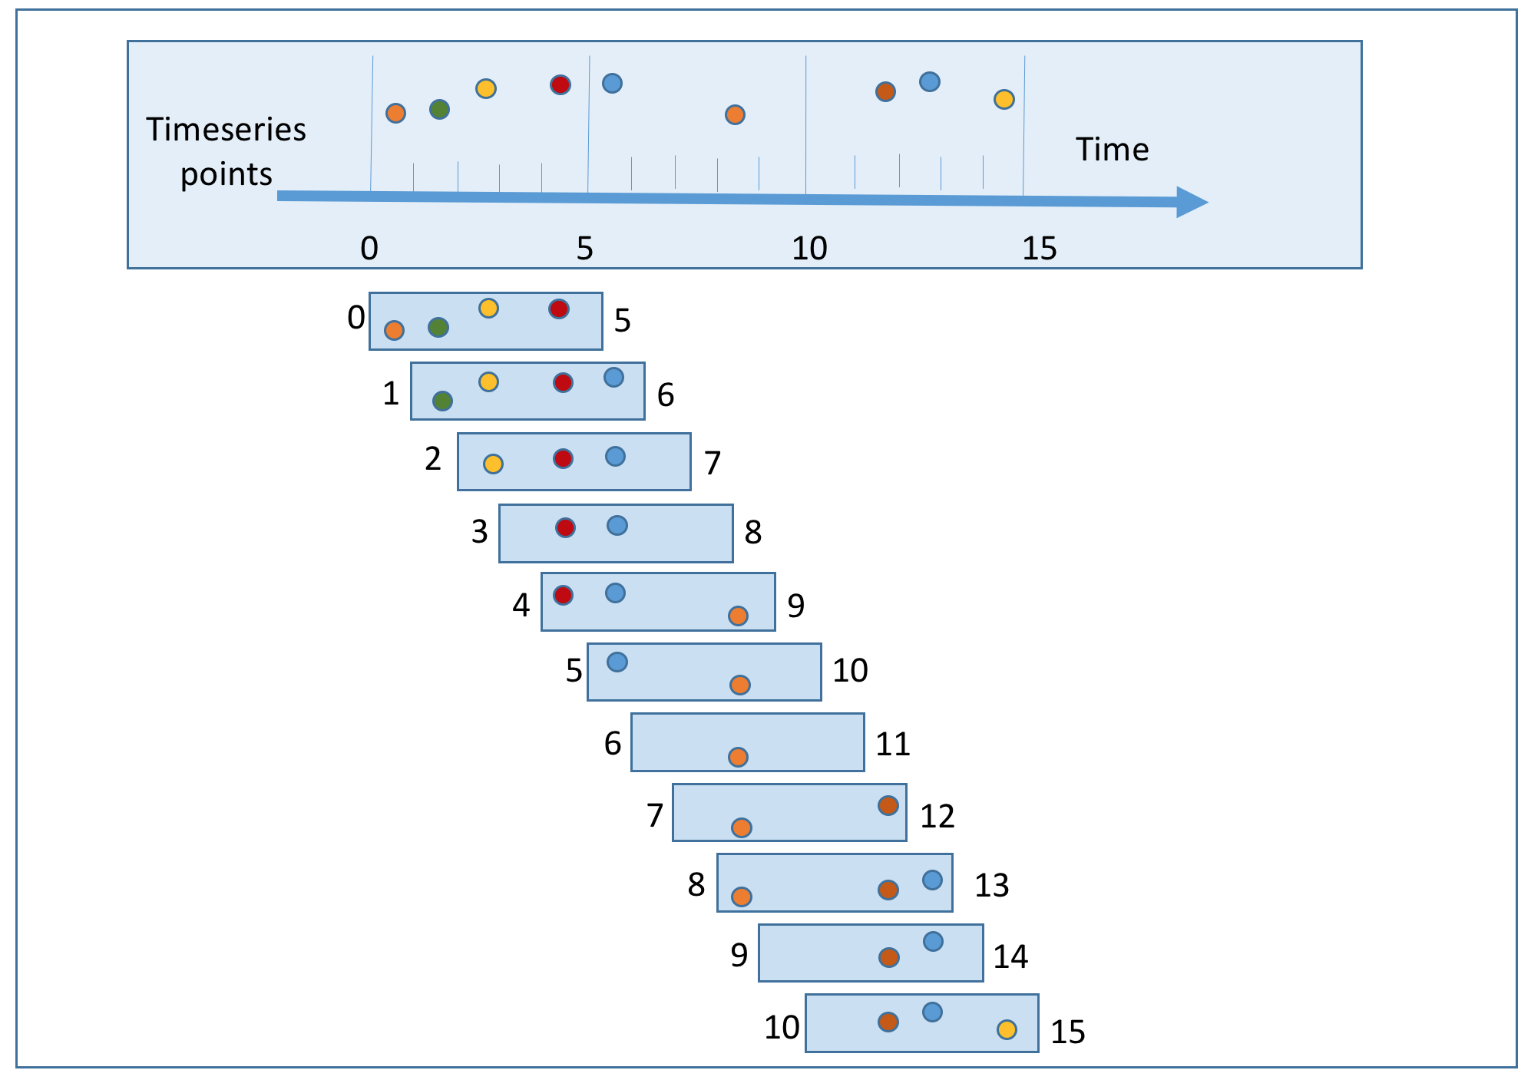
In quantitative finance, slicing your data (e.g., `snp[::5]`) before calculating returns is a **fundamental statistical error**. While it seems to create "5-day gaps," it destroys the integrity of your model in three ways:

#### **1. Massive Information Loss (Sample Size)**
* **Rolling Method (`pct_change(5)`)**: If you have 1000 days of data, this calculates the return from Day 1 to Day 6, Day 2 to Day 7, Day 3 to Day 8, etc. You retain **995 observations**.
* **Slicing Method (`[::5]`)**: You only calculate Day 1 to Day 6, Day 6 to Day 11, etc. You are left with only **200 observations**.

> **Consequence:** You throw away **80% of your data**. In statistics, a smaller sample size leads to higher noise, unstable mean/standard deviation, and "jagged" histograms that do not represent the true distribution.



#### **2. Sampling Bias & Anchor Bias**
Slicing forces you to "anchor" your observations to a specific sequence (e.g., every Monday).
* **The Hidden Risk**: If the market consistently crashes on Fridays and recovers by the following Monday, your sliced data (`[::5]`) will **completely miss the crash**.
* **The Full Picture**: `pct_change(5)` acts like a **sliding scanner**. It captures every possible 5-day path in the market, ensuring that volatility from any day of the week is included in your $\sigma$.

#### **3. Mathematical Inconsistency with GBM**
According to our **Geometric Brownian Motion** formula:
$$R_{t} = \mu \delta t + \sigma \sqrt{\delta t} \phi_{t}$$

* **The Logic**: The parameters $\mu$ and $\sigma$ are intrinsic properties of the **entire asset history**. To observe a 5-day horizon, we should scale the "Global $\sigma$" by $\sqrt{5}$.
* **The Error**: Slicing forces you to calculate a *new* $\sigma$ from a depleted, biased sample. This "Sliced $\sigma$" is a poor and unstable estimator of the asset's true risk.



#### **✅ The Correct Implementation**
Always use the `periods` parameter to maintain the full "power" of your dataset and align with $\delta t = 5$:

```python
# ✅ Correct: Using all 30 years of data to compute rolling 5-day returns
# This provides 5x more data points than slicing!
returns_5d = snp.pct_change(periods=5).dropna()



---


**Question 1: Scaling of σ with time, to the size of δt: compute of returns (1D, 2D or 5D but no longer)**

In [7]:
# Import necessary packages
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

In [8]:
# Use S&P 500 (from 1993 to today) as an example
# We use 'Close' data (it has already taken stock split and dividends into consideration) to compute the returns
snp = yf.download('SPY', start='1993-02-01', progress=False)['Close']                # daily data (1-day gap)

In [9]:
# Compute the returns using two different methods and check if they are equivalent
# --- Method 1: Theoretical Scaling (Based on GBM Formula) ---
# We compute daily parameters and scale them using delta_t
r1d = snp.pct_change(1).dropna()
mu_1d, std_1d = r1d.mean().iloc[0], r1d.std().iloc[0]

# Theoretical 2D and 5D scaling
mean_2d_th, std_2d_th = mu_1d * 2, std_1d * np.sqrt(2)
mean_5d_th, std_5d_th = mu_1d * 5, std_1d * np.sqrt(5)

print(f"Method 1 (Theoretical): 2D({mean_2d_th:.5f}, {std_2d_th:.5f}) | 5D({mean_5d_th:.5f}, {std_5d_th:.5f})")

# --- Method 2: Empirical Observation (Rolling Windows) ---
# We compute returns directly from the dataset using different timesteps (periods)
# This captures all possible rolling paths in the historical data
r2d_emp = snp.pct_change(2).dropna()
r5d_emp = snp.pct_change(5).dropna()

mean_2d_pc, std_2d_pc = r2d_emp.mean().iloc[0], r2d_emp.std().iloc[0]
mean_5d_pc, std_5d_pc = r5d_emp.mean().iloc[0], r5d_emp.std().iloc[0]

print(f"Method 2 (Empirical):   2D({mean_2d_pc:.5f}, {std_2d_pc:.5f}) | 5D({mean_5d_pc:.5f}, {std_5d_pc:.5f})")

# Conclusion
print("\nSuccess: The empirical results closely match the theoretical scaling!")
print("Suprisingly, there are very close!")


Method 1 (Theoretical): 2D(0.00093, 0.01657) | 5D(0.00232, 0.02620)
Method 2 (Empirical):   2D(0.00092, 0.01585) | 5D(0.00225, 0.02379)

Success: The empirical results closely match the theoretical scaling!
Suprisingly, there are very close!




---
**Question 2: Re-shuﬄe the dataset into two non-chronological halves (even / odd observations) and compute µ , σ separately for each half (1D returns only). Compare.**



1.   Compute 1-day returns
2.   Divide the 1-day return column into two halves: even observations and odd observations
3.   Compute the means and stadard deviations for the two halves
4.   Compare if the means and the stds are close


### **Why are we doing this? (The Significance)**

#### **1. Testing the i.i.d. Assumption**
Most financial models (like Geometric Brownian Motion) assume that returns are **Independent and Identically Distributed (i.i.d.)**.
* If this assumption holds, the "Odd" and "Even" halves should be statistical twins.
* If $\mu_{odd} \approx \mu_{even}$ and $\sigma_{odd} \approx \sigma_{even}$, it proves that your parameters are stable and representative of the asset's true nature, rather than just a coincidence of the timeline.



#### **2. Detecting Autocorrelation (Serial Correlation)**
By interleaving the data (Odd vs. Even), we check if today's return is heavily dependent on yesterday's return.
* If the market has strong "memory" or momentum, the two halves might show significant differences when separated.
* A large discrepancy suggests that the "Random Walk" theory might be oversimplified for this specific asset.

#### **3. Eliminating Chronological Bias**
Unlike a "Split-Half" test (comparing 1990-2005 vs. 2006-2021), the Odd/Even split removes the impact of **time-based regimes** (like a long bull market followed by a crash).
* Since both halves cover the exact same 30-year period, they should experience the same macro-economic shocks.
* If they still differ, it indicates that your dataset might contain extreme **outliers** or "fat tails" that are heavily skewing the results of one side.

### **Summary**
The goal of this exercise is to confirm **Statistical Robustness**. It asks: *"Is the $\sigma$ I calculated a universal truth for this stock, or is it just a lucky number produced by the specific way the days were ordered?"*


In [10]:
# Since we have already computed the 1-day return data: r1d

# --- Step 1: Split the already computed 1D returns ---
# odd = [0, 2, 4...], even = [1, 3, 5...]
r1d_odd = r1d.iloc[::2]
r1d_even = r1d.iloc[1::2]

# --- Step 2: Compute parameters for each half ---
mu_odd, std_odd = r1d_odd.mean().iloc[0], r1d_odd.std().iloc[0]
mu_even, std_even = r1d_even.mean().iloc[0], r1d_even.std().iloc[0]

# --- Step 3: Compare results ---
# Using f-strings with precision formatting (.6f) for readability
print(f"Odd Half  | Mean: {mu_odd:.6f} | Std: {std_odd:.6f}")
print(f"Even Half | Mean: {mu_even:.6f} | Std: {std_even:.6f}")
print("-" * 45)
print(f"Difference in Mean: {abs(mu_odd - mu_even):.8f}")
print(f"Difference in Std:  {abs(std_odd - std_even):.8f}")

# Optional: Check if they are within a reasonable 'twin' range
std_ratio = std_odd / std_even
print(f"Volatility Ratio (Odd/Even): {std_ratio:.4f}")

Odd Half  | Mean: 0.000519 | Std: 0.011860
Even Half | Mean: 0.000408 | Std: 0.011576
---------------------------------------------
Difference in Mean: 0.00011120
Difference in Std:  0.00028423
Volatility Ratio (Odd/Even): 1.0246


**Conclusion:** The high consistency in $\mu$ and $\sigma$ across both odd and even subsets ($Volatility\ Ratio \approx 1.02$) confirms the statistical robustness of the dataset and validates the i.i.d. assumption essential for Geometric Brownian Motion.



---

**Question 3: (Mannully and Using Python Package) Construct Quantile-Quantile plots for 1D and 5D returns. The Q-Q plot assumes Normal distribution on horizontal axis – the better the ﬁt between of the empirical returns to Normal distribution, the more observations will be on the diagonal line. Construct a histogram over historical returns scaled to z-scores and compare to Normal distribution density.**

*Method 1: Mannully create normal QQ plot*

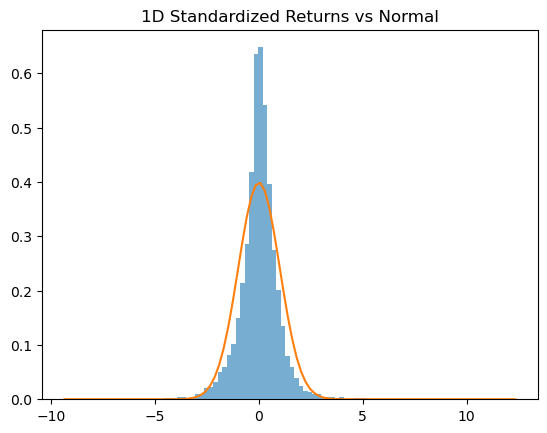

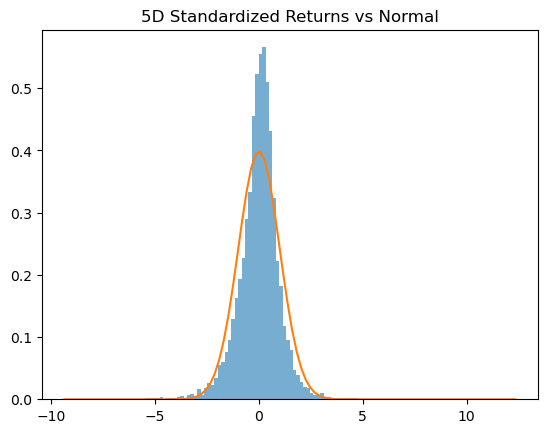

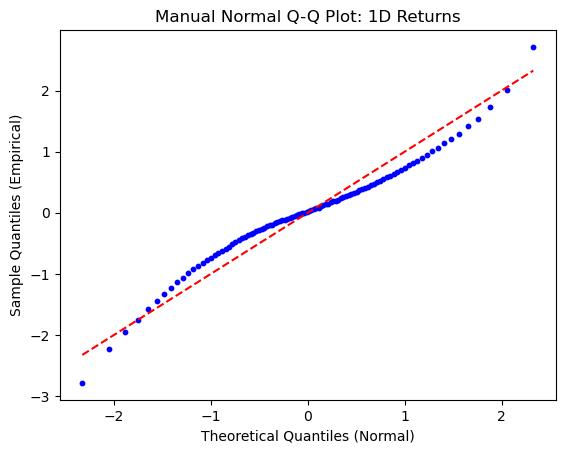

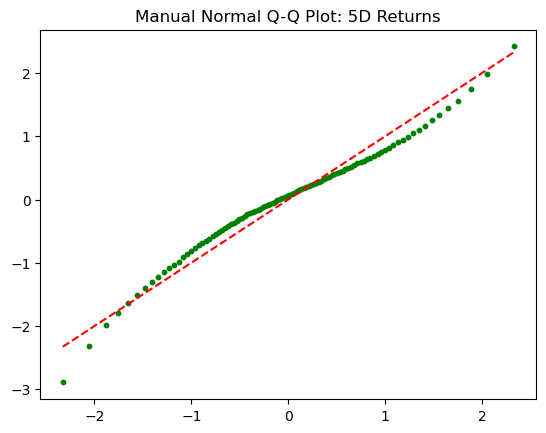

In [11]:
from scipy.stats import norm

# --- Step 1: Standardize Returns ---
r1d_stad = (r1d - mu_1d) / std_1d
r5d_stad = (r5d_emp - mean_5d_pc) / std_5d_pc

# PDF Plot Bounds
r_min = np.min([np.min(r1d_stad), np.min(r5d_stad)])
r_max = np.max([np.max(r1d_stad), np.max(r5d_stad)])

# Theoretical Normal PDF for Histogram Overlay
x_pdf = np.linspace(r_min, r_max, 100)
y_pdf = norm.pdf(x_pdf, 0, 1) # Standard Normal N(0,1)

# --- Step 2: Compare Histograms ---
plt.hist(r1d_stad, bins=100, density=True, alpha=0.6)
plt.plot(x_pdf, y_pdf)
plt.title("1D Standardized Returns vs Normal")
plt.show()

plt.hist(r5d_stad, bins=100, density=True, alpha=0.6)
plt.plot(x_pdf, y_pdf)
plt.title("5D Standardized Returns vs Normal")
plt.show()

# --- Step 3: Manual Q-Q Plot ---

# Use a finer range (1 to 99) to see the "S-curve" clearly
percentile_range = np.linspace(1, 99, 100)

# 1. Empirical Quantiles: The actual values in your data at each percentile
empirical_q1 = np.percentile(r1d_stad, percentile_range)
empirical_q5 = np.percentile(r5d_stad, percentile_range)

# 2. Theoretical Quantiles: Where the values SHOULD be in a perfect Normal distribution
# Note: Use norm.ppf (the inverse of CDF) instead of np.percentile(x)
theoretical_q = norm.ppf(percentile_range / 100)

# --- Plotting the Q-Q results ---

# 1D Q-Q Plot
plt.scatter(theoretical_q, empirical_q1, color='b', s=10)
plt.plot([theoretical_q.min(), theoretical_q.max()],
         [theoretical_q.min(), theoretical_q.max()], color='r', linestyle='--')
plt.title("Manual Normal Q-Q Plot: 1D Returns")
plt.xlabel("Theoretical Quantiles (Normal)")
plt.ylabel("Sample Quantiles (Empirical)")
plt.show()

# 5D Q-Q Plot
plt.scatter(theoretical_q, empirical_q5, color='g', s=10)
plt.plot([theoretical_q.min(), theoretical_q.max()],
         [theoretical_q.min(), theoretical_q.max()], color='r', linestyle='--')
plt.title("Manual Normal Q-Q Plot: 5D Returns")
plt.show()

*Method 2: Using Python package to create normal QQ plot*

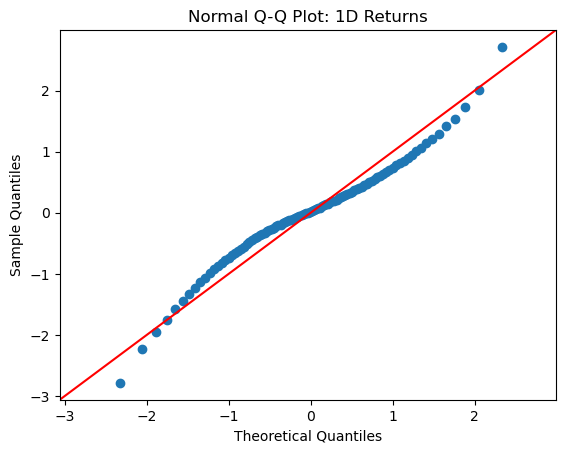

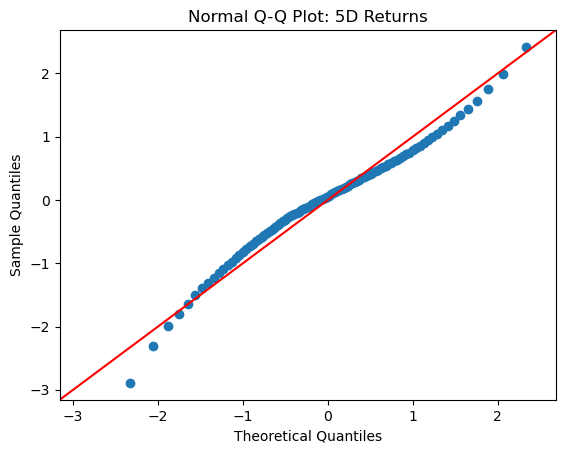

In [12]:
import statsmodels.api as sm

# 1D Normal QQ plot
sm.qqplot(empirical_q1, line='45')
plt.title("Normal Q-Q Plot: 1D Returns")
plt.show()

# 5D Normal QQ plot
sm.qqplot(empirical_q5, line='45')
plt.title("Normal Q-Q Plot: 5D Returns")
plt.show()